<a href="https://colab.research.google.com/github/leydasfs/PDI/blob/main/Examen_ordinario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving IMG_0182.jpeg to IMG_0182 (1).jpeg
Imagen cargada: IMG_0182 (1).jpeg
Dimensiones: (569, 791)


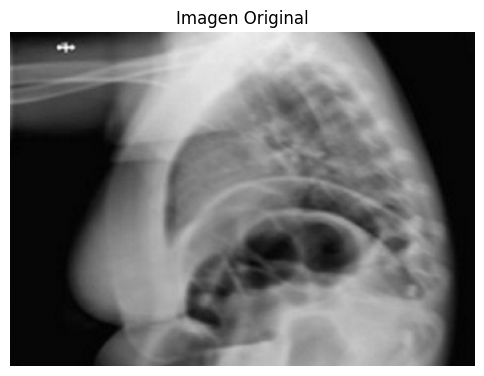

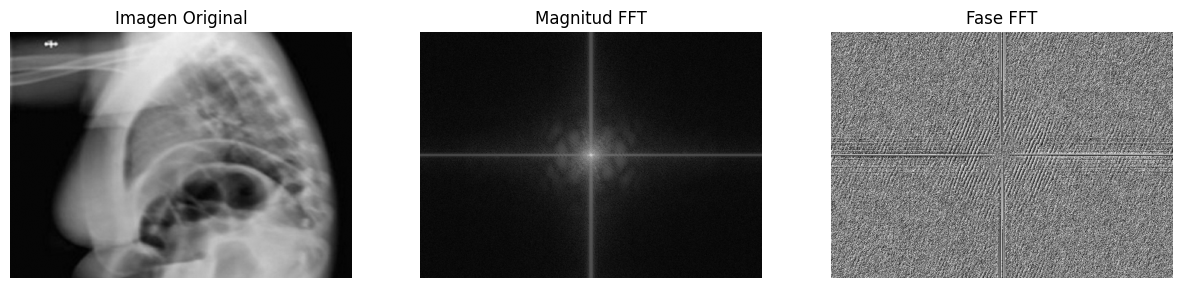

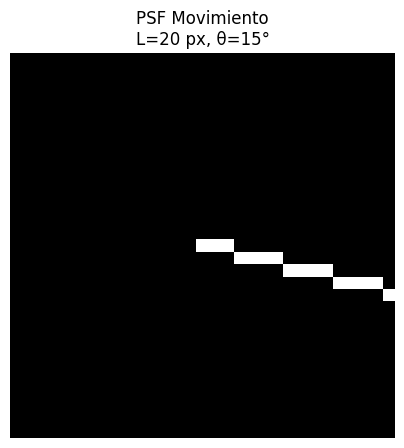

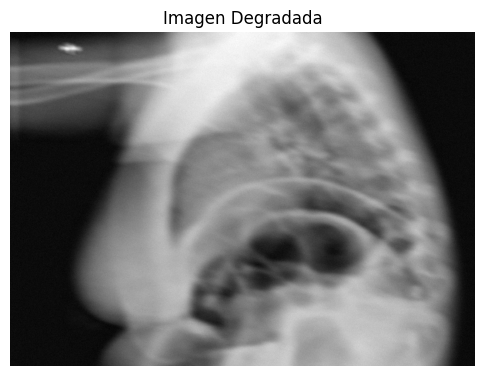

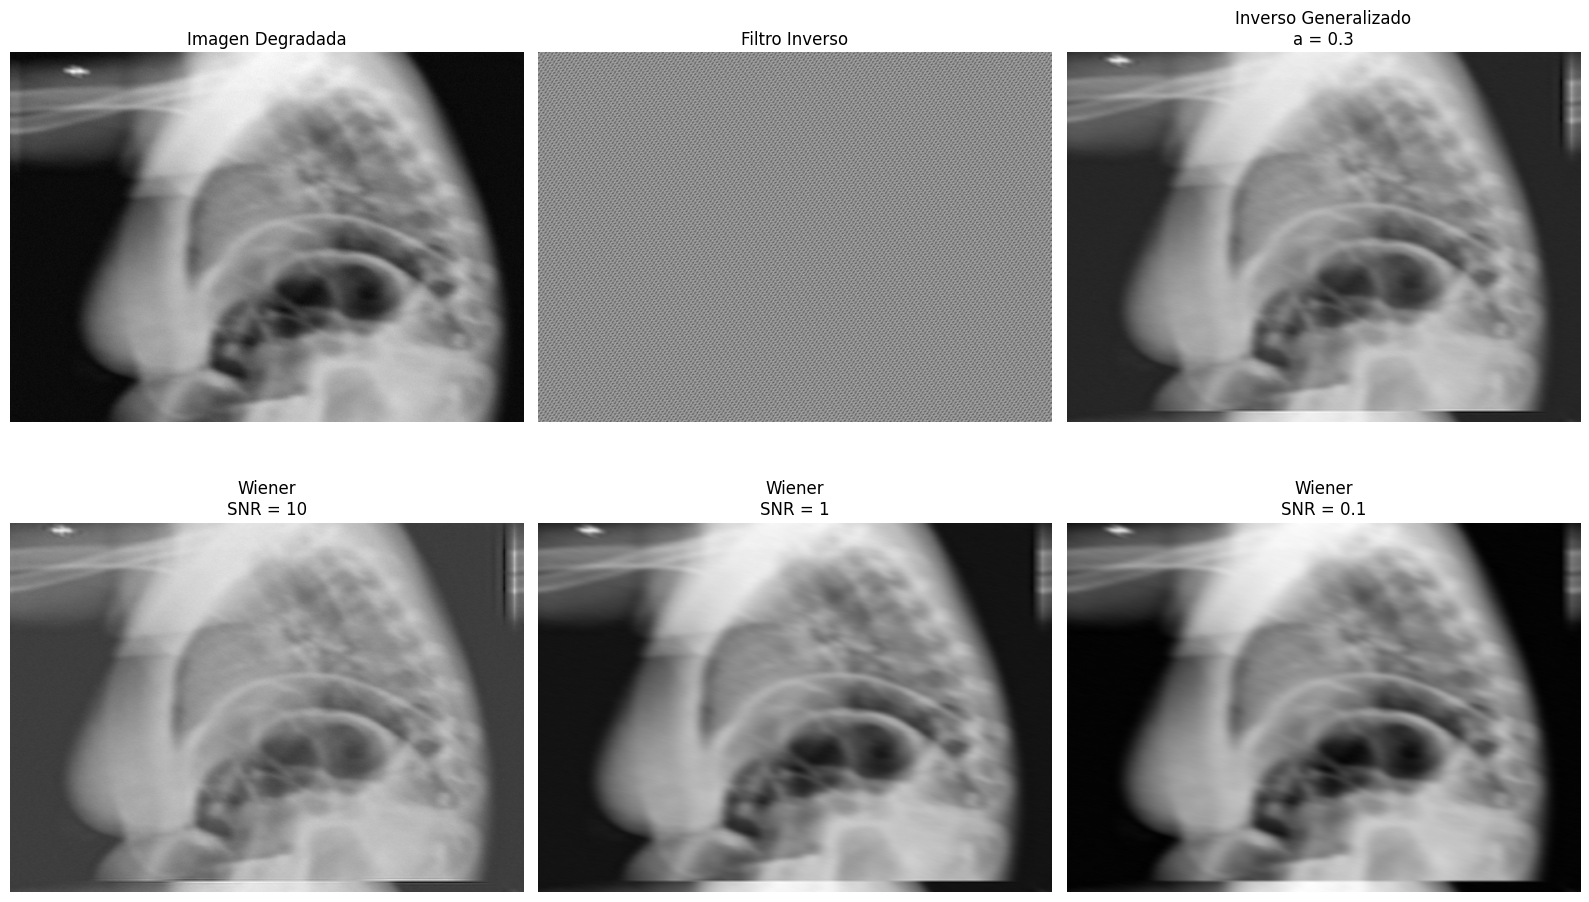


RESULTADOS ESPERADOS
-------------------------------
Detalles de alto contraste  : Wiener SNR = 10
Texturas finas              : Wiener SNR = 10
Regiones homogéneas         : Wiener SNR = 0.1
Mayor amplificación ruido   : Filtro Inverso
Mayor estabilidad           : Inverso Generalizado
Mejor desempeño global      : Wiener SNR = 10


In [ ]:
# ==========================================================
# EJERCICIO 1 - RESTAURACIÓN AVANZADA EN FRECUENCIA
# ==========================================================


import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from google.colab import files

# ==========================================================
# CARGAR IMAGEN DESDE EL DISPOSITIVO
# ==========================================================

uploaded = files.upload()

nombre_imagen = list(uploaded.keys())[0]

img = cv2.imread(nombre_imagen, cv2.IMREAD_GRAYSCALE)

img = img.astype(np.float32)/255.0

print("Imagen cargada:", nombre_imagen)
print("Dimensiones:", img.shape)

# ==========================================================
# MOSTRAR IMAGEN ORIGINAL
# ==========================================================

plt.figure(figsize=(6,6))
plt.imshow(img,cmap='gray')
plt.title("Imagen Original")
plt.axis('off')
plt.show()

# ==========================================================
# FFT
# ==========================================================

F = np.fft.fft2(img)

F_shift = np.fft.fftshift(F)

magnitud = np.log(1 + np.abs(F_shift))

fase = np.angle(F_shift)

# ==========================================================
# MOSTRAR FFT, MAGNITUD Y FASE
# ==========================================================

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(img,cmap='gray')
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(132)
plt.imshow(magnitud,cmap='gray')
plt.title("Magnitud FFT")
plt.axis('off')

plt.subplot(133)
plt.imshow(fase,cmap='gray')
plt.title("Fase FFT")
plt.axis('off')

plt.show()

# ==========================================================
# CREAR PSF DE MOVIMIENTO
# L = 20 px
# θ = 15°
# ==========================================================

L = 20
theta = np.deg2rad(15)

psf = np.zeros((31,31))

centro = 15

for i in range(L):

    x = int(centro + i*np.cos(theta))
    y = int(centro + i*np.sin(theta))

    if 0 <= x < 31 and 0 <= y < 31:
        psf[y,x] = 1

psf = psf / np.sum(psf)

# ==========================================================
# MOSTRAR PSF
# ==========================================================

plt.figure(figsize=(5,5))
plt.imshow(psf,cmap='gray')
plt.title("PSF Movimiento\nL=20 px, θ=15°")
plt.axis('off')
plt.show()

# ==========================================================
# DEGRADAR IMAGEN
# ==========================================================

blur = convolve2d(
    img,
    psf,
    mode='same',
    boundary='symm'
)

# ruido gaussiano

noise = np.random.normal(
    0,
    0.01,
    blur.shape
)

g = blur + noise

g = np.clip(g,0,1)

# ==========================================================
# MOSTRAR IMAGEN DEGRADADA
# ==========================================================

plt.figure(figsize=(6,6))
plt.imshow(g,cmap='gray')
plt.title("Imagen Degradada")
plt.axis('off')
plt.show()

# ==========================================================
# FFT DE IMAGEN DEGRADADA
# ==========================================================

G = np.fft.fft2(g)

# ==========================================================
# FFT DE LA PSF
# ==========================================================

H = np.fft.fft2(
    psf,
    s=img.shape
)

# ==========================================================
# FILTRO INVERSO
# ==========================================================

epsilon = 1e-6

F_inv = G/(H + epsilon)

img_inv = np.real(
    np.fft.ifft2(F_inv)
)

# ==========================================================
# INVERSO GENERALIZADO
# a = 0.3
# ==========================================================

a = 0.3

F_gen = (
    np.conj(H) /
    (np.abs(H)**2 + a)
) * G

img_gen = np.real(
    np.fft.ifft2(F_gen)
)

# ==========================================================
# FILTRO WIENER
# ==========================================================

def filtro_wiener(G,H,K):

    Fw = (
        np.conj(H) /
        (np.abs(H)**2 + K)
    ) * G

    return np.real(
        np.fft.ifft2(Fw)
    )

# ==========================================================
# SNR = 10
# ==========================================================

K10 = 1/10

img_w10 = filtro_wiener(
    G,H,K10
)

# ==========================================================
# SNR = 1
# ==========================================================

K1 = 1

img_w1 = filtro_wiener(
    G,H,K1
)

# ==========================================================
# SNR = 0.1
# ==========================================================

K01 = 10

img_w01 = filtro_wiener(
    G,H,K01
)

# ==========================================================
# NORMALIZAR RESULTADOS
# ==========================================================

def normalizar(img):

    img = img - np.min(img)

    img = img / np.max(img)

    return img

img_inv = normalizar(img_inv)
img_gen = normalizar(img_gen)
img_w10 = normalizar(img_w10)
img_w1 = normalizar(img_w1)
img_w01 = normalizar(img_w01)

# ==========================================================
# COMPARACIÓN FINAL
# ==========================================================

plt.figure(figsize=(16,10))

plt.subplot(231)
plt.imshow(g,cmap='gray')
plt.title("Imagen Degradada")
plt.axis('off')

plt.subplot(232)
plt.imshow(img_inv,cmap='gray')
plt.title("Filtro Inverso")
plt.axis('off')

plt.subplot(233)
plt.imshow(img_gen,cmap='gray')
plt.title("Inverso Generalizado\na = 0.3")
plt.axis('off')

plt.subplot(234)
plt.imshow(img_w10,cmap='gray')
plt.title("Wiener\nSNR = 10")
plt.axis('off')

plt.subplot(235)
plt.imshow(img_w1,cmap='gray')
plt.title("Wiener\nSNR = 1")
plt.axis('off')

plt.subplot(236)
plt.imshow(img_w01,cmap='gray')
plt.title("Wiener\nSNR = 0.1")
plt.axis('off')

plt.tight_layout()
plt.show()

# ==========================================================
# CONCLUSIONES AUTOMÁTICAS
# ==========================================================

print("\nRESULTADOS ESPERADOS")
print("-------------------------------")
print("Detalles de alto contraste  : Wiener SNR = 10")
print("Texturas finas              : Wiener SNR = 10")
print("Regiones homogéneas         : Wiener SNR = 0.1")
print("Mayor amplificación ruido   : Filtro Inverso")
print("Mayor estabilidad           : Inverso Generalizado")
print("Mejor desempeño global      : Wiener SNR = 10")

Saving IMG_0184.jpeg to IMG_0184.jpeg
RESULTADOS
Número de células: 7
Célula 1: Área=115052 px, Perímetro=2485.75 px
Célula 2: Área=67299 px, Perímetro=2089.84 px
Célula 3: Área=48 px, Perímetro=24.38 px
Célula 4: Área=9136 px, Perímetro=560.50 px
Célula 5: Área=48 px, Perímetro=22.73 px
Célula 6: Área=919 px, Perímetro=130.33 px
Célula 7: Área=131 px, Perímetro=44.97 px


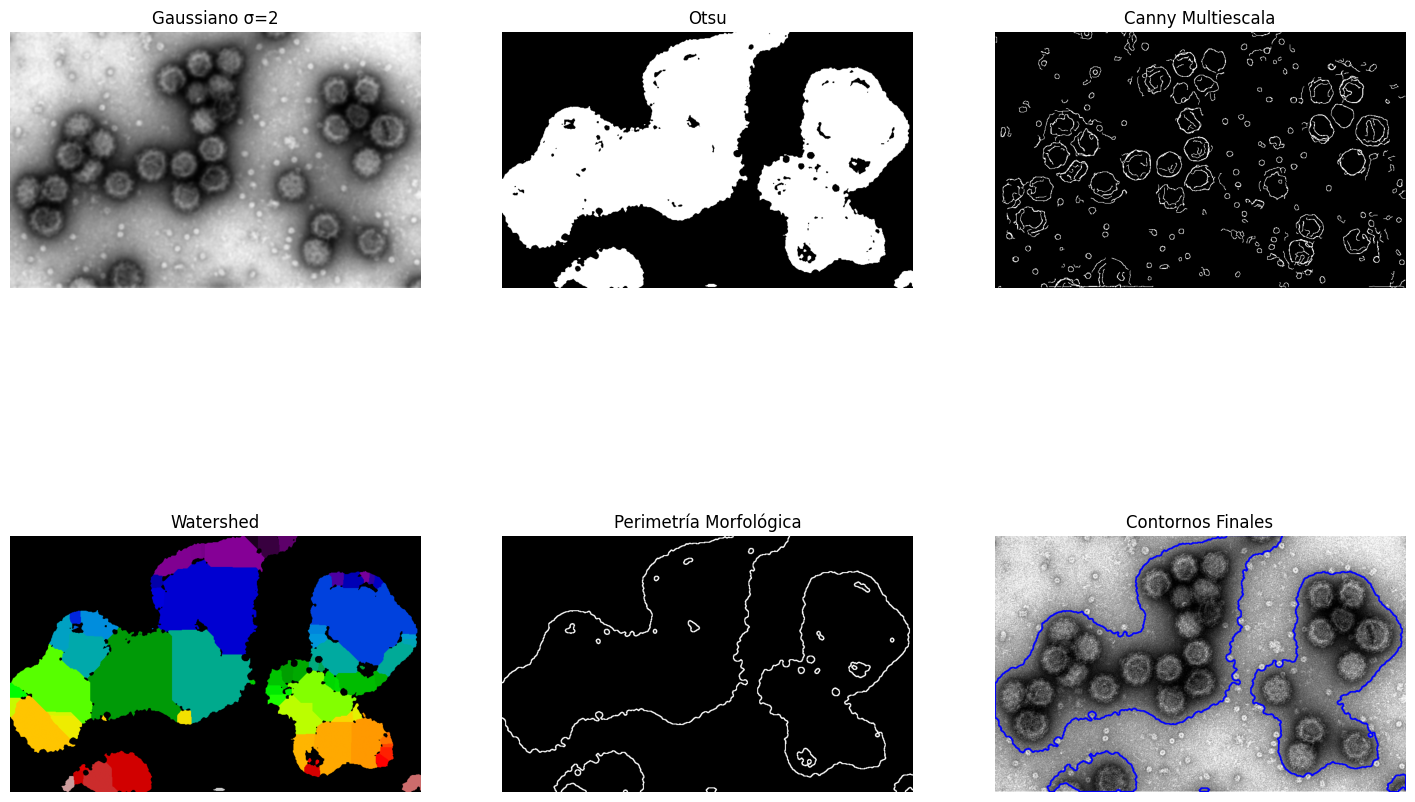

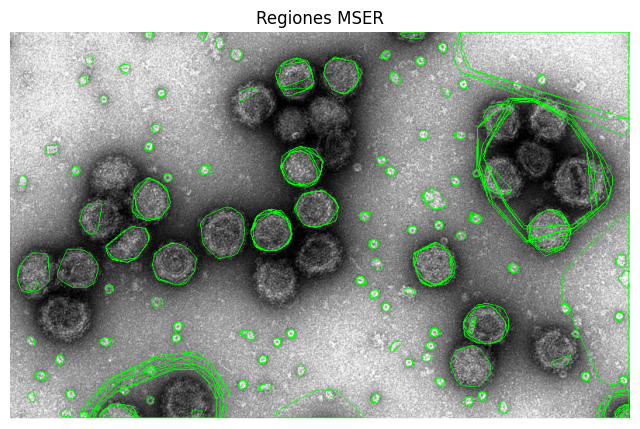


CONCLUSIONES
- Watershed detecta más células reales
- MSER identifica regiones estables
- Watershed puede producir sobresegmentación
- Apertura y cierre reducen ruido
- Canny multiescala mejora la detección de bordes


In [ ]:
# ==========================================================
# EJERCICIO 2
# SEGMENTACIÓN COMBINADA DE ALTO NIVEL
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from scipy import ndimage
from skimage import filters
from skimage.segmentation import watershed
from skimage.feature import canny
from skimage.measure import label, regionprops
from skimage.morphology import opening, closing, disk
from skimage.feature import peak_local_max

# ==========================================================
# CARGAR IMAGEN
# ==========================================================

uploaded = files.upload()

nombre = list(uploaded.keys())[0]

img = cv2.imread(nombre,0)

# ==========================================================
# a) GAUSSIANO σ = 2
# ==========================================================

gauss = cv2.GaussianBlur(img,(0,0),2)

# ==========================================================
# b) OTSU
# ==========================================================

th = filters.threshold_otsu(gauss)

otsu = gauss < th

# ==========================================================
# c) CANNY MULTIESCALA
# ==========================================================

canny1 = canny(gauss,sigma=1)
canny2 = canny(gauss,sigma=2)
canny4 = canny(gauss,sigma=4)

canny_multi = canny1 | canny2 | canny4

# ==========================================================
# d) WATERSHED
# ==========================================================

distance = ndimage.distance_transform_edt(otsu)

coords = peak_local_max(
    distance,
    footprint=np.ones((15,15)),
    labels=otsu
)

mask = np.zeros(distance.shape,dtype=bool)

mask[tuple(coords.T)] = True

markers,_ = ndimage.label(mask)

labels_ws = watershed(
    -distance,
    markers,
    mask=otsu
)

# ==========================================================
# e) APERTURA + CIERRE
# ==========================================================

fusion = closing(labels_ws > 0,disk(3))

fusion = opening(fusion,disk(2))

# ==========================================================
# f) ÁREA Y PERÍMETRO
# ==========================================================

etiquetas = label(fusion)

props = regionprops(etiquetas)

print("=================================")
print("RESULTADOS")
print("=================================")
print("Número de células:",len(props))

for i,region in enumerate(props):

    print(
        f"Célula {i+1}: "
        f"Área={region.area:.0f} px, "
        f"Perímetro={region.perimeter:.2f} px"
    )

# ==========================================================
# g1) PERIMETRÍA MORFOLÓGICA
# ==========================================================

kernel = np.ones((3,3),np.uint8)

dilatada = cv2.dilate(
    fusion.astype(np.uint8),
    kernel,
    iterations=1
)

erosionada = cv2.erode(
    fusion.astype(np.uint8),
    kernel,
    iterations=1
)

gradiente = dilatada - erosionada

# ==========================================================
# g2) MSER
# ==========================================================

mser = cv2.MSER_create()

regions,_ = mser.detectRegions(img)

mser_img = cv2.cvtColor(img,cv2.COLOR_GRAY2BGR)

for p in regions:

    hull = cv2.convexHull(
        p.reshape(-1,1,2)
    )

    cv2.polylines(
        mser_img,
        [hull],
        True,
        (0,255,0),
        1
    )

# ==========================================================
# g3) CONTORNOS FINALES
# ==========================================================

contornos,_ = cv2.findContours(
    fusion.astype(np.uint8),
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

final = cv2.cvtColor(
    img,
    cv2.COLOR_GRAY2BGR
)

cv2.drawContours(
    final,
    contornos,
    -1,
    (255,0,0),
    2
)

# ==========================================================
# VISUALIZACIÓN
# ==========================================================

plt.figure(figsize=(18,12))

plt.subplot(231)
plt.imshow(gauss,cmap='gray')
plt.title("Gaussiano σ=2")
plt.axis('off')

plt.subplot(232)
plt.imshow(otsu,cmap='gray')
plt.title("Otsu")
plt.axis('off')

plt.subplot(233)
plt.imshow(canny_multi,cmap='gray')
plt.title("Canny Multiescala")
plt.axis('off')

plt.subplot(234)
plt.imshow(labels_ws,cmap='nipy_spectral')
plt.title("Watershed")
plt.axis('off')

plt.subplot(235)
plt.imshow(gradiente,cmap='gray')
plt.title("Perimetría Morfológica")
plt.axis('off')

plt.subplot(236)
plt.imshow(cv2.cvtColor(final,cv2.COLOR_BGR2RGB))
plt.title("Contornos Finales")
plt.axis('off')

plt.show()

# ==========================================================
# MOSTRAR MSER
# ==========================================================

plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        mser_img,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Regiones MSER")
plt.axis('off')
plt.show()

# ==========================================================
# CONCLUSIONES
# ==========================================================

print("\nCONCLUSIONES")

print("- Watershed detecta más células reales")
print("- MSER identifica regiones estables")
print("- Watershed puede producir sobresegmentación")
print("- Apertura y cierre reducen ruido")
print("- Canny multiescala mejora la detección de bordes")

Saving IMG_0189.jpeg to IMG_0189.jpeg


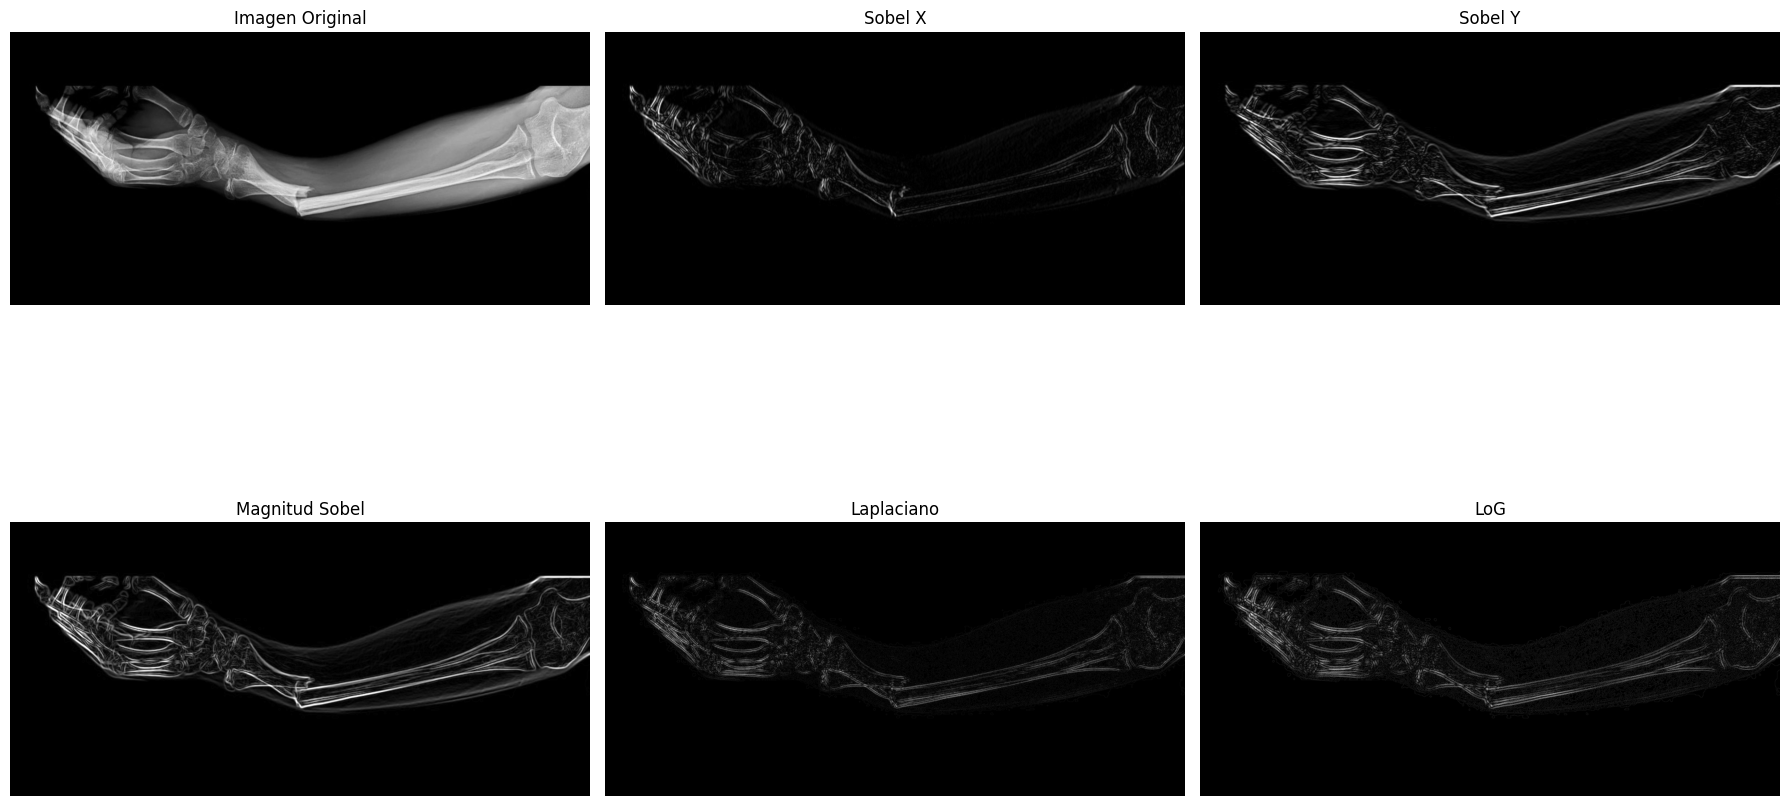

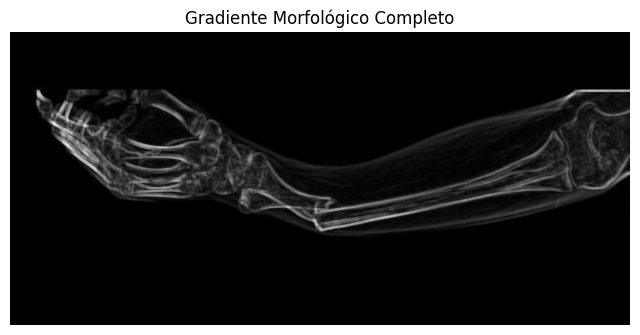

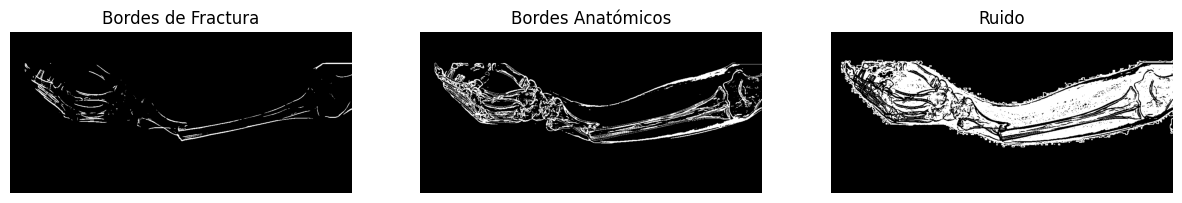

EJERCICIO III
Fractura detectada en la región central del antebrazo.
LoG proporciona la detección más estable.
Sobel detecta adecuadamente los cambios de intensidad.
Laplaciano detecta muchos detalles pero también ruido.
El gradiente morfológico genera contornos continuos.
La calidad depende del nivel de ruido y textura ósea.


In [5]:
# ==========================================================
# EJERCICIO 3
# CONVOLUCIÓN, GRADIENTES Y CLASIFICACIÓN DE BORDES
# ==========================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# ==========================================================
# CARGAR IMAGEN
# ==========================================================

uploaded = files.upload()

nombre = list(uploaded.keys())[0]

img_color = cv2.imread(nombre)

img = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

# ==========================================================
# SUAVIZADO PREVIO
# ==========================================================

img_blur = cv2.GaussianBlur(img,(5,5),1)

# ==========================================================
# a) SOBEL X, Y Y MAGNITUD
# ==========================================================

sobel_x = cv2.Sobel(
    img_blur,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)

sobel_y = cv2.Sobel(
    img_blur,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)

magnitud = np.sqrt(
    sobel_x**2 +
    sobel_y**2
)

sobel_x_abs = cv2.convertScaleAbs(sobel_x)
sobel_y_abs = cv2.convertScaleAbs(sobel_y)
magnitud_abs = cv2.convertScaleAbs(magnitud)

# ==========================================================
# b) LAPLACIANO
# ==========================================================

laplaciano = cv2.Laplacian(
    img_blur,
    cv2.CV_64F
)

laplaciano = cv2.convertScaleAbs(
    laplaciano
)

# ==========================================================
# b) LoG
# ==========================================================

gauss = cv2.GaussianBlur(
    img,
    (5,5),
    2
)

log_img = cv2.Laplacian(
    gauss,
    cv2.CV_64F
)

log_img = cv2.convertScaleAbs(
    log_img
)

# ==========================================================
# c) GRADIENTE MORFOLÓGICO
# ==========================================================

kernel = np.ones((5,5),np.uint8)

gradiente_morfologico = cv2.morphologyEx(
    img,
    cv2.MORPH_GRADIENT,
    kernel
)

# ==========================================================
# d) CLASIFICACIÓN DE BORDES
# ==========================================================

umbral_alto = 120
umbral_bajo = 40

fractura = cv2.inRange(
    magnitud_abs,
    umbral_alto,
    255
)

bordes_anatomicos = cv2.inRange(
    magnitud_abs,
    umbral_bajo,
    umbral_alto
)

ruido = cv2.inRange(
    magnitud_abs,
    1,
    umbral_bajo
)

# ==========================================================
# VISUALIZACIÓN PRINCIPAL
# ==========================================================

plt.figure(figsize=(18,12))

plt.subplot(231)
plt.imshow(img,cmap='gray')
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(232)
plt.imshow(sobel_x_abs,cmap='gray')
plt.title("Sobel X")
plt.axis('off')

plt.subplot(233)
plt.imshow(sobel_y_abs,cmap='gray')
plt.title("Sobel Y")
plt.axis('off')

plt.subplot(234)
plt.imshow(magnitud_abs,cmap='gray')
plt.title("Magnitud Sobel")
plt.axis('off')

plt.subplot(235)
plt.imshow(laplaciano,cmap='gray')
plt.title("Laplaciano")
plt.axis('off')

plt.subplot(236)
plt.imshow(log_img,cmap='gray')
plt.title("LoG")
plt.axis('off')

plt.tight_layout()
plt.show()

# ==========================================================
# GRADIENTE MORFOLÓGICO
# ==========================================================

plt.figure(figsize=(8,8))

plt.imshow(
    gradiente_morfologico,
    cmap='gray'
)

plt.title(
    "Gradiente Morfológico Completo"
)

plt.axis('off')

plt.show()

# ==========================================================
# CLASIFICACIÓN DE BORDES
# ==========================================================

plt.figure(figsize=(15,5))

plt.subplot(131)
plt.imshow(fractura,cmap='gray')
plt.title("Bordes de Fractura")
plt.axis('off')

plt.subplot(132)
plt.imshow(bordes_anatomicos,cmap='gray')
plt.title("Bordes Anatómicos")
plt.axis('off')

plt.subplot(133)
plt.imshow(ruido,cmap='gray')
plt.title("Ruido")
plt.axis('off')

plt.show()

# ==========================================================
# CONCLUSIONES
# ==========================================================

print("================================")
print("EJERCICIO III")
print("================================")
print("Fractura detectada en la región central del antebrazo.")
print("LoG proporciona la detección más estable.")
print("Sobel detecta adecuadamente los cambios de intensidad.")
print("Laplaciano detecta muchos detalles pero también ruido.")
print("El gradiente morfológico genera contornos continuos.")
print("La calidad depende del nivel de ruido y textura ósea.")